# Waveoptics: focusing with an ideal lens

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

try:
    import srxraylib.plot.gol as _gol
    _gol.set_qt = lambda: None
except Exception:
    pass


SRW is not available
SRW is not available
pixelsize:  6.510416666666666e-07


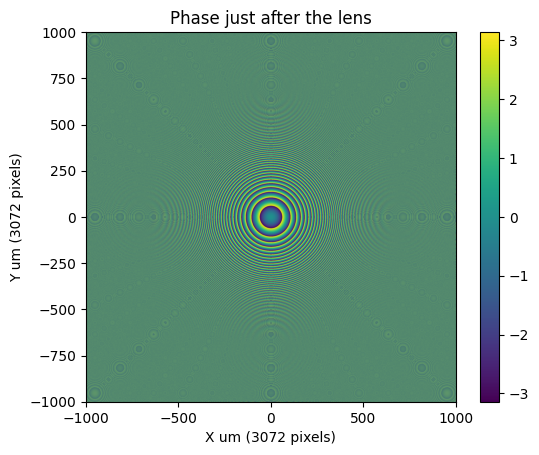


#                                                             
# near field fresnel (fresnel (fft)) diffraction and focusing  
#                                                             
Incident intensity:  9437184.0


/tmp/ipykernel_1982053/853402134.py:87: DeprecationWarning: Call to deprecated function propagate_2D_fresnel (use wofry and wofrylib, instead).
  wf = propagate_2D_fresnel(wf, propagation_distance*defocus_factor/propagation_steps)


FWHM of the horizontal profile: 0.651254 um
FWHM of the vertical profile: 0.651254 um
Output intensity:  9437184.000000022

#                                                             
# near field fresnel (fresnel (convolution)) diffraction and focusing  
#                                                             
Incident intensity:  9437184.0


/tmp/ipykernel_1982053/853402134.py:89: DeprecationWarning: Call to deprecated function propagate_2D_fresnel_convolution (use wofry and wofrylib, instead).
  wf = propagate_2D_fresnel_convolution(wf, propagation_distance*defocus_factor/propagation_steps)


FWHM of the horizontal profile: 0.651254 um
FWHM of the vertical profile: 0.651254 um
Output intensity:  5.243128424713081e+31


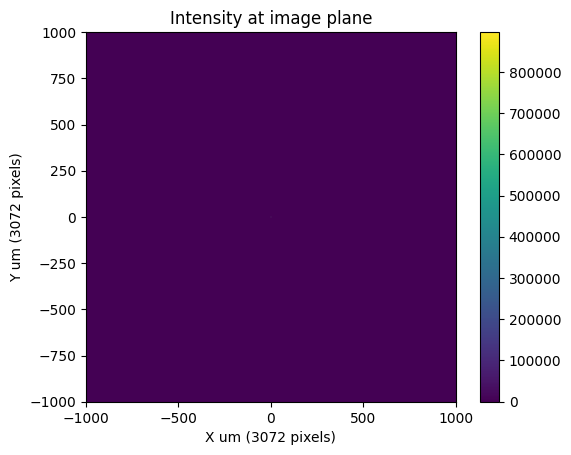

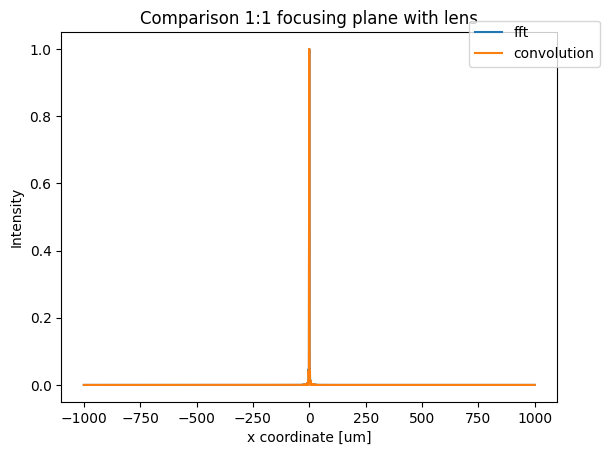

In [2]:
"""

    This example shows the focusing of an ideal lens in 1:1 configuration
    for different sources (see main program at the bottom)

    The systems are:
        'convergent spherical'
        'divergent spherical with lens'
        'plane with lens'
        'Gaussian with lens'
        'Hermite with lens'
        'Undulator with lens'

"""
import numpy

from srxraylib.waveoptics.wavefront2D  import Wavefront2D
from srxraylib.waveoptics.propagator2D import propagate_2D_fraunhofer
from srxraylib.waveoptics.propagator2D import propagate_2D_fresnel, propagate_2D_fresnel_convolution, propagate_2D_fresnel_srw
from scipy.special import hermite
import scipy.constants as codata

# this is undulator block
from pySRU.ElectronBeam import ElectronBeam
from pySRU.MagneticStructureUndulatorPlane import MagneticStructureUndulatorPlane
from pySRU.TrajectoryFactory import TrajectoryFactory, TRAJECTORY_METHOD_ANALYTIC,TRAJECTORY_METHOD_ODE
from pySRU.RadiationFactory import RadiationFactory,RADIATION_METHOD_NEAR_FIELD, RADIATION_METHOD_APPROX_FARFIELD
from pySRU.SourceUndulatorPlane import SourceUndulatorPlane

try:
    import oasys_srw.srwlib as srwlib
    SRWLIB_AVAILABLE = True
except:
    SRWLIB_AVAILABLE = False
    print("SRW is not available")

SRWLIB_AVAILABLE = False
# global variables
codata_mee = numpy.array(codata.physical_constants["electron mass energy equivalent in MeV"][0])
m2ev = codata.c * codata.h / codata.e      # lambda(m)  = m2eV / energy(eV)

do_plot = True

if do_plot:
    from srxraylib.plot.gol import plot,plot_image,plot_table

#
# auxiliar functions
#

def line_fwhm(line):
    #
    #CALCULATE fwhm in number of abscissas bins (supposed on a regular grid)
    #
    tt = numpy.where(line>=max(line)*0.5)
    if line[tt].size > 1:
        # binSize = x[1]-x[0]
        FWHM = (tt[0][-1]-tt[0][0])
        return FWHM
    else:
        return -1


def propagation_to_image(wf,do_plot=do_plot,plot_title="Before lens",method='fft',
                            propagation_distance=30.0,defocus_factor=1.0,propagation_steps=1,show=1):


    method_label = "fresnel (%s)"%method
    print("\n#                                                             ")
    print("# near field fresnel (%s) diffraction and focusing  "%(method_label))
    print("#                                                             ")

    #                               \ |  /
    #   *           /users/pirro/Documents/workspace/syned                | | |                      *
    #                               / | \
    #   <-------    d  ---------------><---------   d   ------->
    #   d is propagation_distance

    print("Incident intensity: ",wf.get_intensity().sum())

    # propagation downstream the lens to image plane
    for i in range(propagation_steps):
        if propagation_steps > 1:
            print(">>> Propagating step %d of %d; propagation_distance=%g m"%(i+1,propagation_steps,
                                                propagation_distance*defocus_factor/propagation_steps))
        if method == 'fft':
            wf = propagate_2D_fresnel(wf, propagation_distance*defocus_factor/propagation_steps)
        elif method == 'convolution':
            wf = propagate_2D_fresnel_convolution(wf, propagation_distance*defocus_factor/propagation_steps)
        elif method == 'srw':
            wf = propagate_2D_fresnel_srw(wf, propagation_distance*defocus_factor/propagation_steps)
        elif method == 'fraunhofer':
            wf = propagate_2D_fraunhofer(wf, propagation_distance*defocus_factor/propagation_steps)
        else:
            raise Exception("Not implemented method: %s"%method)



    horizontal_profile = wf.get_intensity()[:,int(wf.size()[1]/2)]
    horizontal_profile /= horizontal_profile.max()
    print("FWHM of the horizontal profile: %g um"%(1e6*line_fwhm(horizontal_profile)*wf.delta()[0]))
    vertical_profile = wf.get_intensity()[int(wf.size()[0]/2),:]
    vertical_profile /= vertical_profile.max()
    print("FWHM of the vertical profile: %g um"%(1e6*line_fwhm(vertical_profile)*wf.delta()[1]))

    if do_plot:
        from srxraylib.plot.gol import plot,plot_image
        plot_image(wf.get_intensity(),1e6*wf.get_coordinate_x(),1e6*wf.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf.size()[0]),ytitle="Y um (%d pixels)",title='intensity (%s)'%method,show=False)
        plot_image(wf.get_phase(),1e6*wf.get_coordinate_x(),1e6*wf.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf.size()[0]),ytitle="Y um (%d pixels)"%(wf.size[1]),title='phase (%s)'%method,show=False)

        plot(wf.get_coordinate_x(),horizontal_profile,
             wf.get_coordinate_y(),vertical_profile,
             legend=['Horizontal profile','Vertical profile'],title="%s %s"%(plot_title,method),show=show)

    print("Output intensity: ",wf.get_intensity().sum())
    return wf,wf.get_coordinate_x(),horizontal_profile


#
# main function
#

def main(mode_wavefront_before_lens):

    lens_diameter = 0.002 # 0.001 # 0.002

    if mode_wavefront_before_lens == 'Undulator with lens':
        npixels_x = 512
    else:
        npixels_x = int(2048*1.5)

    pixelsize_x = lens_diameter / npixels_x
    print("pixelsize: ",pixelsize_x)


    pixelsize_y = pixelsize_x
    npixels_y = npixels_x

    wavelength = 1.24e-10
    propagation_distance = 30.0
    defocus_factor = 1.0 # 1.0 is at focus
    propagation_steps = 1

    # for Gaussian source
    sigma_x = lens_diameter / 400 # 5e-6
    sigma_y = sigma_x # 5e-6
    # for Hermite-Gauss, the H and V mode index (start from 0)
    hm = 3
    hn = 1

    #
    # initialize wavefronts of dimension equal to the lens
    #
    wf_fft = Wavefront2D.initialize_wavefront_from_range(x_min=-pixelsize_x*npixels_x/2,x_max=pixelsize_x*npixels_x/2,
                                                     y_min=-pixelsize_y*npixels_y/2,y_max=pixelsize_y*npixels_y/2,
                                                     number_of_points=(npixels_x,npixels_y),wavelength=wavelength)

    wf_convolution = Wavefront2D.initialize_wavefront_from_range(x_min=-pixelsize_x*npixels_x/2,x_max=pixelsize_x*npixels_x/2,
                                                     y_min=-pixelsize_y*npixels_y/2,y_max=pixelsize_y*npixels_y/2,
                                                     number_of_points=(npixels_x,npixels_y),wavelength=wavelength)
    if SRWLIB_AVAILABLE:
        wf_srw = Wavefront2D.initialize_wavefront_from_range(x_min=-pixelsize_x*npixels_x/2,x_max=pixelsize_x*npixels_x/2,
                                                     y_min=-pixelsize_y*npixels_y/2,y_max=pixelsize_y*npixels_y/2,
                                                     number_of_points=(npixels_x,npixels_y),wavelength=wavelength)

    #
    # calculate/define wavefront at zero distance downstream the lens
    #
    if mode_wavefront_before_lens == 'convergent spherical':
        # no need to propagate nor define lens
        wf_fft.set_spherical_wave(complex_amplitude=1.0,radius=-propagation_distance)
        wf_convolution.set_spherical_wave(complex_amplitude=1.0,radius=-propagation_distance)
        if SRWLIB_AVAILABLE: wf_srw.set_spherical_wave(complex_amplitude=1.0,radius=-propagation_distance)

    elif mode_wavefront_before_lens == 'divergent spherical with lens':
        # define wavefront at zero distance upstream the lens and apply lens
        focal_length = propagation_distance / 2.

        wf_fft.set_spherical_wave(complex_amplitude=1.0,radius=propagation_distance)
        wf_fft.apply_ideal_lens(focal_length,focal_length)

        wf_convolution.set_spherical_wave(complex_amplitude=1.0,radius=propagation_distance)
        wf_convolution.apply_ideal_lens(focal_length,focal_length)

        if SRWLIB_AVAILABLE:
            wf_srw.set_spherical_wave(complex_amplitude=1.0,radius=propagation_distance)
            wf_srw.apply_ideal_lens(focal_length,focal_length)

    elif mode_wavefront_before_lens == 'plane with lens':
        # define wavefront at zero distance upstream the lens and apply lens
        focal_length = propagation_distance

        wf_fft.set_plane_wave_from_complex_amplitude(1.0+0j)
        wf_fft.apply_ideal_lens(focal_length,focal_length)

        wf_convolution.set_plane_wave_from_complex_amplitude(1.0+0j)
        wf_convolution.apply_ideal_lens(focal_length,focal_length)

        if SRWLIB_AVAILABLE:
            wf_srw.set_plane_wave_from_complex_amplitude(1.0+0j)
            wf_srw.apply_ideal_lens(focal_length,focal_length)

    elif mode_wavefront_before_lens == 'Gaussian with lens':
        # define wavefront at source point, propagate to the lens and apply lens
        X = wf_fft.get_mesh_x()
        Y = wf_fft.get_mesh_y()

        intensity = numpy.exp( - X**2/(2*sigma_x**2)) * numpy.exp( - Y**2/(2*sigma_y**2))


        wf_fft.set_complex_amplitude( numpy.sqrt(intensity) )
        wf_convolution.set_complex_amplitude( numpy.sqrt(intensity) )
        if SRWLIB_AVAILABLE: wf_srw.set_complex_amplitude( numpy.sqrt(intensity) )

        # plot

        plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[1]),title="Gaussian source",show=1)

        wf_fft, tmp1, tmp2 = propagation_to_image(wf_fft,method='fft',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")
        wf_convolution, tmp1, tmp2 = propagation_to_image(wf_convolution,method='convolution',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")
        if SRWLIB_AVAILABLE:
            wf_srw, tmp1, tmp2 = propagation_to_image(wf_srw,method='srw',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")


        plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um",title="Before lens fft",show=1)

        plot_image(wf_convolution.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_convolution.size()[0]),ytitle="Y um",title="Before lens convolution",show=1)

        focal_length = propagation_distance / 2

        wf_fft.apply_ideal_lens(focal_length,focal_length)
        wf_convolution.apply_ideal_lens(focal_length,focal_length)
        if SRWLIB_AVAILABLE: wf_srw.apply_ideal_lens(focal_length,focal_length)

    elif mode_wavefront_before_lens == 'Hermite with lens':
        # define wavefront at source point, propagate to the lens and apply lens
        X = wf_fft.get_mesh_x()
        Y = wf_fft.get_mesh_y()

        efield =     (hermite(hm)(numpy.sqrt(2)*X/sigma_x)*numpy.exp(-X**2/sigma_x**2))**2 \
                   * (hermite(hn)(numpy.sqrt(2)*Y/sigma_y)*numpy.exp(-Y**2/sigma_y**2))**2

        wf_fft.set_complex_amplitude( efield )
        wf_convolution.set_complex_amplitude( efield )
        if SRWLIB_AVAILABLE: wf_srw.set_complex_amplitude( efield )

        # plot

        plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),title="Hermite-Gauss source",show=1)

        wf_fft, tmp1, tmp2 = propagation_to_image(wf_fft,method='fft',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")
        wf_convolution, tmp1, tmp2 = propagation_to_image(wf_convolution,method='convolution',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")
        if SRWLIB_AVAILABLE:
            wf_srw, tmp1, tmp2 = propagation_to_image(wf_srw,method='srw',propagation_distance=propagation_distance,
                                              do_plot=0,plot_title="Before lens")


        plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),title="Before lens fft",show=1)

        plot_image(wf_convolution.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),title="Before lens convolution",show=1)

        focal_length = propagation_distance / 2

        wf_fft.apply_ideal_lens(focal_length,focal_length)
        wf_convolution.apply_ideal_lens(focal_length,focal_length)
        if SRWLIB_AVAILABLE: wf_srw.apply_ideal_lens(focal_length,focal_length)

    elif mode_wavefront_before_lens == 'Undulator with lens':

        beamline = {}
        beamline['ElectronCurrent'] = 0.2
        beamline['ElectronEnergy']  = 6.0
        beamline['Kv']              = 1.68  # 1.87
        beamline['NPeriods']        = 111   # 14
        beamline['PeriodID']        = 0.018 # 0.035
        beamline['distance']        =   propagation_distance

        gamma = beamline['ElectronEnergy'] / (codata_mee * 1e-3)
        print ("Gamma: %f \n"%(gamma))

        resonance_wavelength = (1 + beamline['Kv']**2 / 2.0) / 2 / gamma**2 * beamline["PeriodID"]
        resonance_energy = m2ev / resonance_wavelength


        print ("Resonance wavelength [A]: %g \n"%(1e10*resonance_wavelength))
        print ("Resonance energy [eV]: %g \n"%(resonance_energy))

        # red shift 100 eV
        resonance_energy = resonance_energy - 100


        myBeam = ElectronBeam(Electron_energy=beamline['ElectronEnergy'], I_current=beamline['ElectronCurrent'])
        myUndulator = MagneticStructureUndulatorPlane(K=beamline['Kv'], period_length=beamline['PeriodID'],
                            length=beamline['PeriodID']*beamline['NPeriods'])


        XX = wf_fft.get_mesh_x()
        YY = wf_fft.get_mesh_y()
        X = wf_fft.get_coordinate_x()
        Y = wf_fft.get_coordinate_y()

        source = SourceUndulatorPlane(undulator=myUndulator,
                            electron_beam=myBeam, magnetic_field=None)
        omega = resonance_energy * codata.e / codata.hbar
        Nb_pts_trajectory = int(source.choose_nb_pts_trajectory(0.01,photon_frequency=omega))
        print("Number of trajectory points: ",Nb_pts_trajectory)


        traj_fact = TrajectoryFactory(Nb_pts=Nb_pts_trajectory,method=TRAJECTORY_METHOD_ODE,
                                      initial_condition=None)

        print("Number of trajectory points: ",traj_fact.Nb_pts)

        if (traj_fact.initial_condition == None):
            traj_fact.initial_condition = source.choose_initial_contidion_automatic()

        print("Number of trajectory points: ",traj_fact.Nb_pts,traj_fact.initial_condition)
        #print('step 2')

        rad_fact = RadiationFactory(method=RADIATION_METHOD_NEAR_FIELD, photon_frequency=omega)


        #print('step 3')
        trajectory = traj_fact.create_from_source(source=source)


        #print('step 4')
        radiation = rad_fact.create_for_one_relativistic_electron(trajectory=trajectory, source=source,
                            XY_are_list=False,distance=beamline['distance'], X=X, Y=Y)

        efield = rad_fact.calculate_electrical_field(trajectory=trajectory,source=source,
                            distance=beamline['distance'],X_array=XX,Y_array=YY)

        tmp = efield.electrical_field()[:,:,0]


        wf_fft.set_photon_energy(resonance_energy)
        wf_convolution.set_photon_energy(resonance_energy)
        if SRWLIB_AVAILABLE: wf_srw.set_photon_energy(resonance_energy)

        wf_fft.set_complex_amplitude( tmp )
        wf_convolution.set_complex_amplitude( numpy.sqrt(tmp) )
        if SRWLIB_AVAILABLE: wf_srw.set_complex_amplitude( numpy.sqrt(tmp) )

        # plot

        plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
                   xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),title="UND source at lens plane",show=1)

        # apply lens

        focal_length = propagation_distance / 2

        wf_fft.apply_ideal_lens(focal_length,focal_length)
        wf_convolution.apply_ideal_lens(focal_length,focal_length)
        if SRWLIB_AVAILABLE: wf_srw.apply_ideal_lens(focal_length,focal_length)

    else:
        raise Exception("Unknown mode")


    plot_image(wf_fft.get_phase(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
               title="Phase just after the lens",xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),show=1)

    wf_fft, x_fft, y_fft = propagation_to_image(wf_fft,do_plot=0,method='fft',
                            propagation_steps=propagation_steps,
                            propagation_distance = propagation_distance, defocus_factor=defocus_factor)

    wf_convolution, x_convolution, y_convolution = propagation_to_image(wf_convolution,do_plot=0,method='convolution',
                            propagation_steps=propagation_steps,
                            propagation_distance = propagation_distance, defocus_factor=defocus_factor)
    if SRWLIB_AVAILABLE:
        wf_srw, x_srw, y_srw = propagation_to_image(wf_srw,do_plot=0,method='srw',
                                propagation_steps=propagation_steps,
                                propagation_distance = propagation_distance, defocus_factor=defocus_factor)

    plot_image(wf_fft.get_intensity(),1e6*wf_fft.get_coordinate_x(),1e6*wf_fft.get_coordinate_y(),
               title="Intensity at image plane",xtitle="X um (%d pixels)"%(wf_fft.size()[0]),ytitle="Y um (%d pixels)"%(wf_fft.size()[0]),show=1)

    if do_plot:
        if SRWLIB_AVAILABLE:
            x = x_fft
            y = numpy.vstack((y_fft,y_srw,y_convolution))

            plot_table(1e6*x,y,legend=["fft","srw","convolution"],ytitle="Intensity",xtitle="x coordinate [um]",
                       title="Comparison 1:1 focusing "+mode_wavefront_before_lens)
        else:
            x = x_fft
            y = numpy.vstack((y_fft,y_convolution))

            plot_table(1e6*x,y,legend=["fft","convolution"],ytitle="Intensity",xtitle="x coordinate [um]",
                       title="Comparison 1:1 focusing "+mode_wavefront_before_lens)

if __name__ == "__main__":

    mode_wavefront_before_lens = 'convergent spherical'
    # mode_wavefront_before_lens = 'divergent spherical with lens'
    mode_wavefront_before_lens = 'plane with lens'
    # mode_wavefront_before_lens = 'Gaussian with lens'
    # mode_wavefront_before_lens = 'Hermite with lens'
    # mode_wavefront_before_lens = 'Undulator with lens'

    main(mode_wavefront_before_lens)
